# Evaluation: Response-Aware Dialogue Caching

In this notebook, we analyse the empirical results of the caching experiments (Phase 1 of the artefact evaluation). The goal is to validate the mechanics of the *Response-Aware Dialogue Caching* and quantify the operational savings generated by the growing dialogue tree.

### Experimental Setup
The dataset originates from a simulated CI/CD environment. The simulation executed **30 dialogue repetitions** across **5 distinct cached roots**.

The setup used the following deterministic hyperparameters:
* **Context Expansion:** `alpha = 2`, `beta = 3`, `dir = below`
* **Validation:** `safeguard = True`
* **CG Persona:** `Your questions are very short and precise`

### Data Structure & Organisation
Each root is assigned a unique identifier (`root_id`). This ID serves as the primary key connecting all associated data files, which share the same UID in their filenames across different directories:
* **`tree/`**: Contains a `.json` file storing the recursive branches of the cache tree that grow from this root.
* **`conversations/`**: Contains the `.log` and `.jsonl` files of the generated multi-turn conversations.
* **`measurements/`**: Contains a `.jsonl` file logging the exact turn-by-turn metrics, including latency, token consumption, semantic similarity scores, and the Conversation Validator's (CV) accept/reject decisions.

**Methodological Note:** During the simulation, the system always retrieved the cached node with the highest semantic similarity *without* enforcing a lower bound ($\tau$). For every interaction, the exact similarity score, the final accept or reject decision by the Conversation Validator (CV), execution latencies, and token consumption were logged. This continuous logging approach allows us to retrospectively simulate and evaluate the system's behaviour across various threshold limits in this notebook.

### Objectives of this Analysis

This notebook focuses on two core analyses:

1. **Similarity Threshold Calibration (Confusion Matrix)**
   By matching the logged similarity scores against the actual CV decisions, we construct a confusion matrix for varying $\tau$ values. We investigate the ratio of Safe Hits (True Positives) to Dangerous Hits (False Positives) to identify the empirical sweet spot that maximises cache utilisation while minimising costly CV rejections within our experimental setup.

2. **Cache Efficiency Over Time (Growth Plots)**
   We visualise the temporal development of the cache over the 30 iterations. Using the logged latency and token metrics, we demonstrate how the continuous expansion of the dialogue tree progressively reduces the need for fresh generations. These plots aim to show how quickly the system reaches a stable state and confirm whether the caching mechanism delivers tangible operational value.

## Data Preparation

connect multi-hop / single-hop flags, `type` and `logic_type` with measurements table and load everything to pandas

In [8]:
import pandas as pd
import json
from pathlib import Path

# 1. Pfade zu deinen Ordnern definieren (ausgehend vom wkdir)
measurements_dir = Path("measurements")
conversations_dir = Path("conversations")

all_merged_data = []

# 2. Gehe alle Measurement-Dateien durch
for meas_file in measurements_dir.glob("*.jsonl"):
    uid = meas_file.stem 
    conv_file = conversations_dir / f"{uid}.jsonl"
    
    if not conv_file.exists():
        print(f"Warnung: Keine Conversation-Datei für UID {uid} gefunden.")
        continue 

    # 3. Measurements laden
    df_meas = pd.read_json(meas_file, lines=True)
    
    # 4. Conversation laden und sauber mit conversation_id mappen
    conv_rows = []
    with open(conv_file, "r", encoding="utf-8") as f:
        # idx iteriert über die Zeilen (also die 30 Dialog-Iterationen)
        for idx, line in enumerate(f):
            data = json.loads(line)
            
            # Entweder das JSON hat die ID, oder wir nehmen die Zeilennummer (1 bis 30)
            conv_id = data.get("conversation_id", idx + 1)
            
            for turn in data.get("conversation", []):
                # JSON ist 0-basiert, Measurements sind 1-basiert
                turn_idx = turn.get("turn_index", 0) 
                
                conv_rows.append({
                    "conversation_id": conv_id,  # WICHTIG: Die ID muss hier rein!
                    "turn_index": turn_idx,
                    "multi_hop_flag": turn.get("multi_hop_flag"),
                    "type": turn.get("type"),
                    "logic_type": turn.get("logic_type"),
                })
                
    df_conv = pd.DataFrame(conv_rows)
    
    # 5. Zusammenführen über BEIDE Spalten (ID und Turn)
    if not df_conv.empty and not df_meas.empty:
        # Jetzt mappt er exakt 1:1
        df_merged = pd.merge(df_conv, df_meas, on=["conversation_id", "turn_index"], how="left")
        
        # Measurement-Spalten bei Turn 0 mit 0 füllen
        meas_cols = [c for c in df_meas.columns if c not in ["conversation_id", "turn_index"]]
        df_merged.loc[df_merged["turn_index"] == 0, meas_cols] = 0        
        # UID zur Übersicht hinzufügen
        df_merged.insert(0, "uid", uid) 
        
        all_merged_data.append(df_merged)

# 6. Master-DataFrame bauen
if all_merged_data:
    df_final = pd.concat(all_merged_data, ignore_index=True)
    
    print(df_final.head())
    df_final.to_csv("evaluation_dataset_full.csv", index=False)
    print(f"\nErfolgreich! {len(df_final)} Turns aus {len(all_merged_data)} Dateien zusammengeführt.")
else:
    print("Es konnten keine Daten zusammengeführt werden.")

                                    uid  conversation_id  turn_index  \
0  bfeeeccc-65bf-4dfd-bff6-483a1d9e6fe1                1           0   
1  bfeeeccc-65bf-4dfd-bff6-483a1d9e6fe1                1           1   
2  bfeeeccc-65bf-4dfd-bff6-483a1d9e6fe1                1           2   
3  bfeeeccc-65bf-4dfd-bff6-483a1d9e6fe1                1           3   
4  bfeeeccc-65bf-4dfd-bff6-483a1d9e6fe1                1           4   

   multi_hop_flag       type  logic_type cache_available  candidates_count  \
0               1    Initial  comparison               0               0.0   
1               1  Follow-up  comparison            True               1.0   
2               1  Follow-up  comparison            True               1.0   
3               0  Follow-up        none            True               1.0   
4               0  Follow-up        none           False               0.0   

   highest_sim  validator_passed cache_accepted_and_used  generation_retries  \
0       0.0000    

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Akademisches Styling für deine Masterarbeit
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# Lade das DataFrame (falls nicht schon im Speicher)
df = pd.read_csv("evaluation_dataset_full.csv")

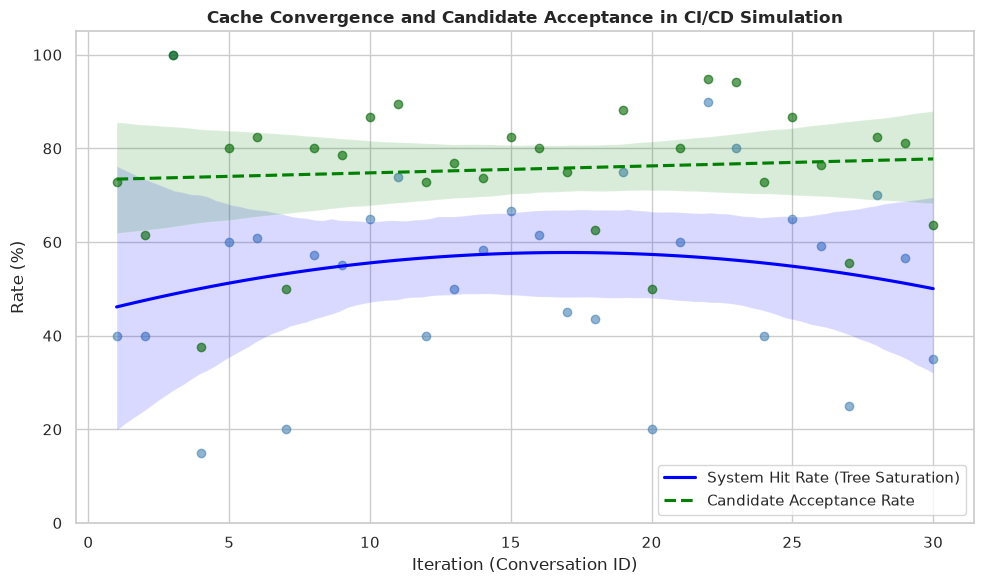

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Akademisches Styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# 1. Datenvorbereitung (Booleans fixen)
df_ongoing = df[df['turn_index'] > 0].copy()
df_ongoing['cache_accepted'] = df_ongoing['cache_accepted_and_used'].isin([True, 'True', 1, 1.0])
df_ongoing['cache_avail'] = df_ongoing['cache_available'].isin([True, 'True', 1, 1.0])

# 2. Metrik A: System Hit Rate (Zeigt die Sättigung des Baumes)
# Basis: ALLE generierten Turns. Wie viel % der Turns konnten aus dem Cache bedient werden?
system_hit_rate = df_ongoing.groupby('conversation_id')['cache_accepted'].mean() * 100

# 3. Metrik B: Candidate Acceptance Rate (Dein Gedanke!)
# Basis: NUR Turns, bei denen der Vector-Cache einen Kandidaten hatte. Wie oft sagte der Validator "Ja"?
df_candidates_only = df_ongoing[df_ongoing['cache_avail'] == True]
acceptance_rate = df_candidates_only.groupby('conversation_id')['cache_accepted'].mean() * 100


# 4. Plotten
plt.figure(figsize=(10, 6))

# Sättigungskurve (System Hit Rate)
sns.regplot(x=system_hit_rate.index, y=system_hit_rate.values, 
            scatter_kws={'alpha':0.6, 'color': 'steelblue'}, 
            line_kws={'color':'blue', 'label':'System Hit Rate (Tree Saturation)'},
            order=2)

# Acceptance Rate (Validator Quote)
sns.regplot(x=acceptance_rate.index, y=acceptance_rate.values, 
            scatter_kws={'alpha':0.6, 'color': 'darkgreen', 'marker': 'x'}, 
            line_kws={'color':'green', 'linestyle': '--', 'label':'Candidate Acceptance Rate'},
            order=1)

plt.title('Cache Convergence and Candidate Acceptance in CI/CD Simulation', fontweight='bold')
plt.xlabel('Iteration (Conversation ID)')
plt.ylabel('Rate (%)')
plt.ylim(0, 105)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('cache_convergence_combined.pdf')
plt.show()

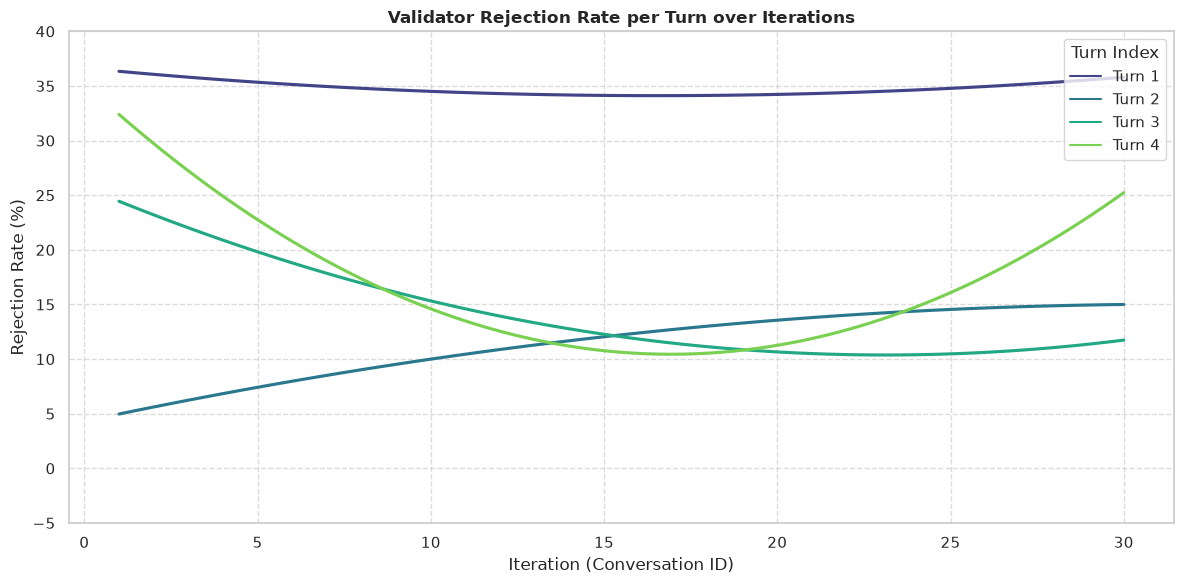

In [31]:
df_validatable = df[df['cache_available'].isin([True, 'True', 1, 1.0])].copy()
df_validatable['validator_passed_num'] = pd.to_numeric(df_validatable['validator_passed'], errors='coerce')
df_clean = df_validatable.dropna(subset=['validator_passed_num', 'turn_index'])

df_clean['rejected'] = (df_clean['validator_passed_num'] == 0).astype(int) * 100

plt.figure(figsize=(12, 6))

import matplotlib.lines as mlines

handles = []
for idx, turn in enumerate(sorted(df_clean['turn_index'].unique())):
    subset = df_clean[df_clean['turn_index'] == turn]
    color = sns.color_palette('viridis', len(df_clean['turn_index'].unique()))[idx]
    sns.regplot(
        x='conversation_id', y='rejected', data=subset,
        scatter=False, color=color,
        line_kws={}, order=2, ci=None
    )
    handles.append(mlines.Line2D([], [], color=color, label=f'Turn {int(turn)}'))

plt.legend(handles=handles, title='Turn Index', loc='upper right')

plt.title('Validator Rejection Rate per Turn over Iterations', fontweight='bold')
plt.xlabel('Iteration (Conversation ID)')
plt.ylabel('Rejection Rate (%)')
plt.ylim(-5, 40)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('rejection_rate_per_turn.pdf')
plt.show()

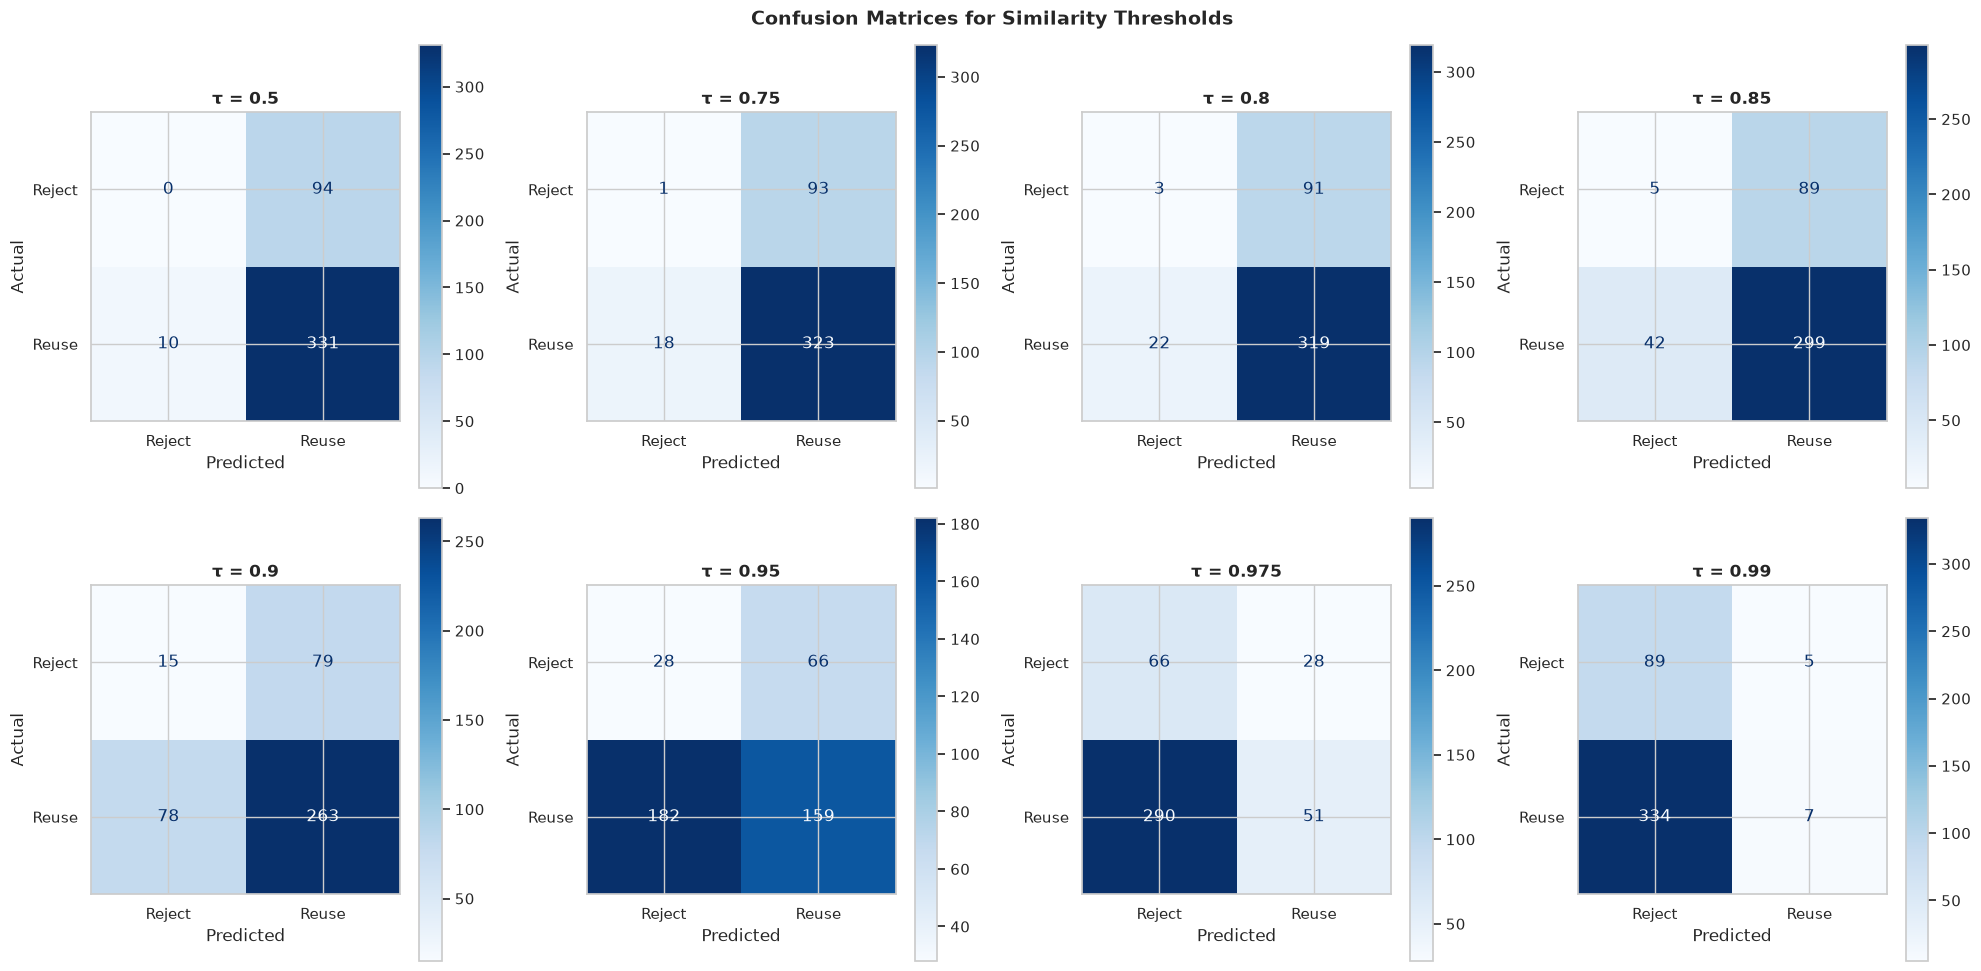

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

df_cache = df[df['cache_available'].isin([True, 'True', 1, 1.0])].copy()
df_cache['accepted'] = df_cache['cache_accepted_and_used'].isin([True, 'True', 1, 1.0]).astype(int)
df_cache['highest_sim'] = pd.to_numeric(df_cache['highest_sim'], errors='coerce')
df_cache = df_cache.dropna(subset=['highest_sim'])

thresholds = [0.5, 0.75, 0.8, 0.85, 0.9, 0.95, 0.975, 0.99]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, tau in enumerate(thresholds):
    predicted = (df_cache['highest_sim'] >= tau).astype(int)  # 1=reuse, 0=reject
    actual = df_cache['accepted']                              # 1=accepted, 0=rejected
    
    cm = confusion_matrix(actual, predicted, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Reject', 'Reuse'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'τ = {tau}', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices for Similarity Thresholds', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices_thresholds.pdf')
plt.show()

                     Cache Hit (Accepted)  Cache Miss (Rejected)  \
gen_tokens_in                        0.00                1947.44   
gen_tokens_out                       0.00                 379.22   
val_tokens_in                     2528.06                5575.56   
val_tokens_out                     938.26                1736.34   
generator_time_sec                   0.00                   2.36   
validator_time_sec                  11.33                  20.78   
total_turn_time_sec                 23.44                  55.28   

                     No Cache (Pure Gen)  
gen_tokens_in                    7571.43  
gen_tokens_out                    418.01  
val_tokens_in                   11799.90  
val_tokens_out                   2131.79  
generator_time_sec                  2.66  
validator_time_sec                 25.47  
total_turn_time_sec                41.92  


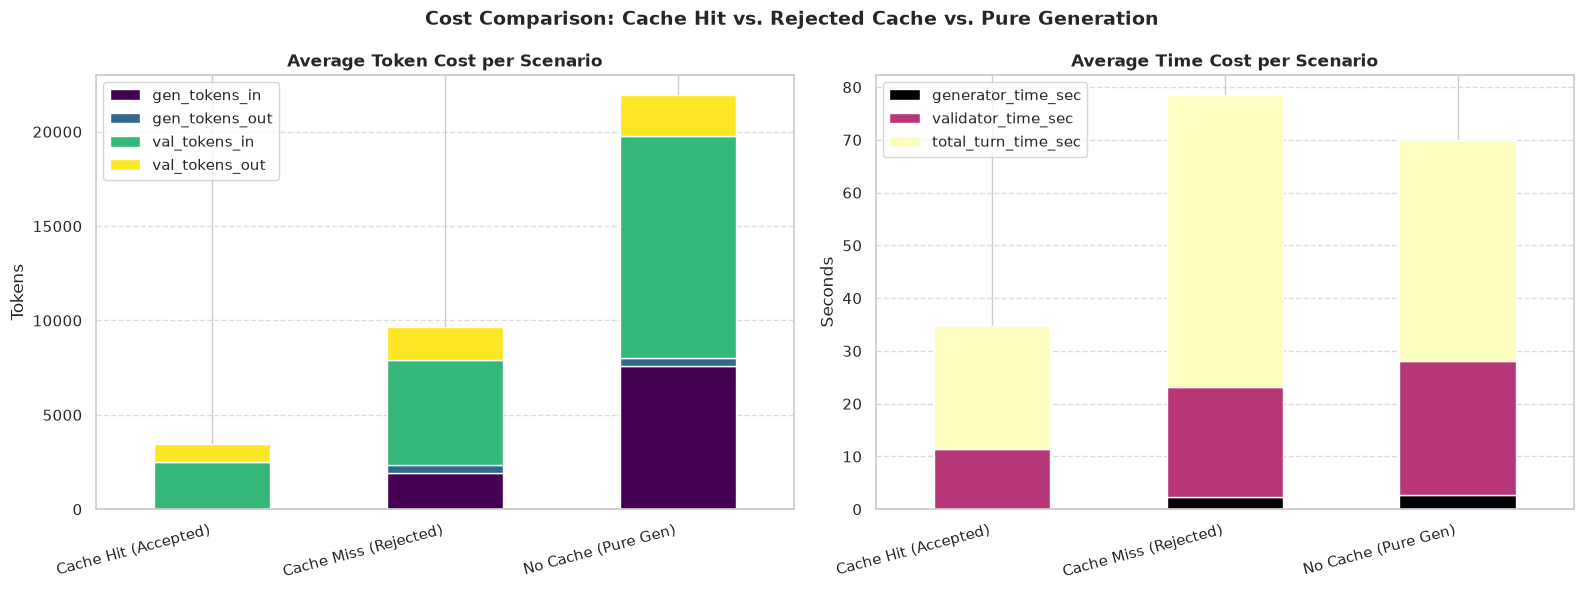

In [34]:
df_turns = df[df['turn_index'] > 0].copy()
df_turns['cache_avail'] = df_turns['cache_available'].isin([True, 'True', 1, 1.0])
df_turns['cache_accepted'] = df_turns['cache_accepted_and_used'].isin([True, 'True', 1, 1.0])

# Drei Szenarien
df_rejected = df_turns[(df_turns['cache_avail']) & (~df_turns['cache_accepted'])]  # Cache da, aber abgelehnt
df_no_cache = df_turns[~df_turns['cache_avail']]                                   # Kein Cache vorhanden
df_cache_hit = df_turns[(df_turns['cache_avail']) & (df_turns['cache_accepted'])]   # Cache akzeptiert

# Token-Kosten
token_cols = ['gen_tokens_in', 'gen_tokens_out', 'val_tokens_in', 'val_tokens_out']
time_cols = ['generator_time_sec', 'validator_time_sec', 'total_turn_time_sec']

for col in token_cols + time_cols:
    df_turns[col] = pd.to_numeric(df_turns[col], errors='coerce').fillna(0)

# Zusammenfassung
summary = pd.DataFrame({
    'Cache Hit (Accepted)': df_cache_hit[token_cols + time_cols].mean(),
    'Cache Miss (Rejected)': df_rejected[token_cols + time_cols].mean(),
    'No Cache (Pure Gen)': df_no_cache[token_cols + time_cols].mean(),
})

print(summary.round(2))

# ============ Plot 1: Tokens ============
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

token_data = summary.loc[token_cols].T
token_data['total_tokens'] = token_data.sum(axis=1)
token_data[['gen_tokens_in', 'gen_tokens_out', 'val_tokens_in', 'val_tokens_out']].plot(
    kind='bar', stacked=True, ax=ax1, colormap='viridis'
)
ax1.set_title('Average Token Cost per Scenario', fontweight='bold')
ax1.set_ylabel('Tokens')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15, ha='right')
ax1.legend(loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# ============ Plot 2: Time ============
time_data = summary.loc[time_cols].T
time_data.plot(kind='bar', stacked=True, ax=ax2, colormap='magma')
ax2.set_title('Average Time Cost per Scenario', fontweight='bold')
ax2.set_ylabel('Seconds')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=15, ha='right')
ax2.legend(loc='upper left')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Cost Comparison: Cache Hit vs. Rejected Cache vs. Pure Generation', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('cost_comparison.pdf')
plt.show()

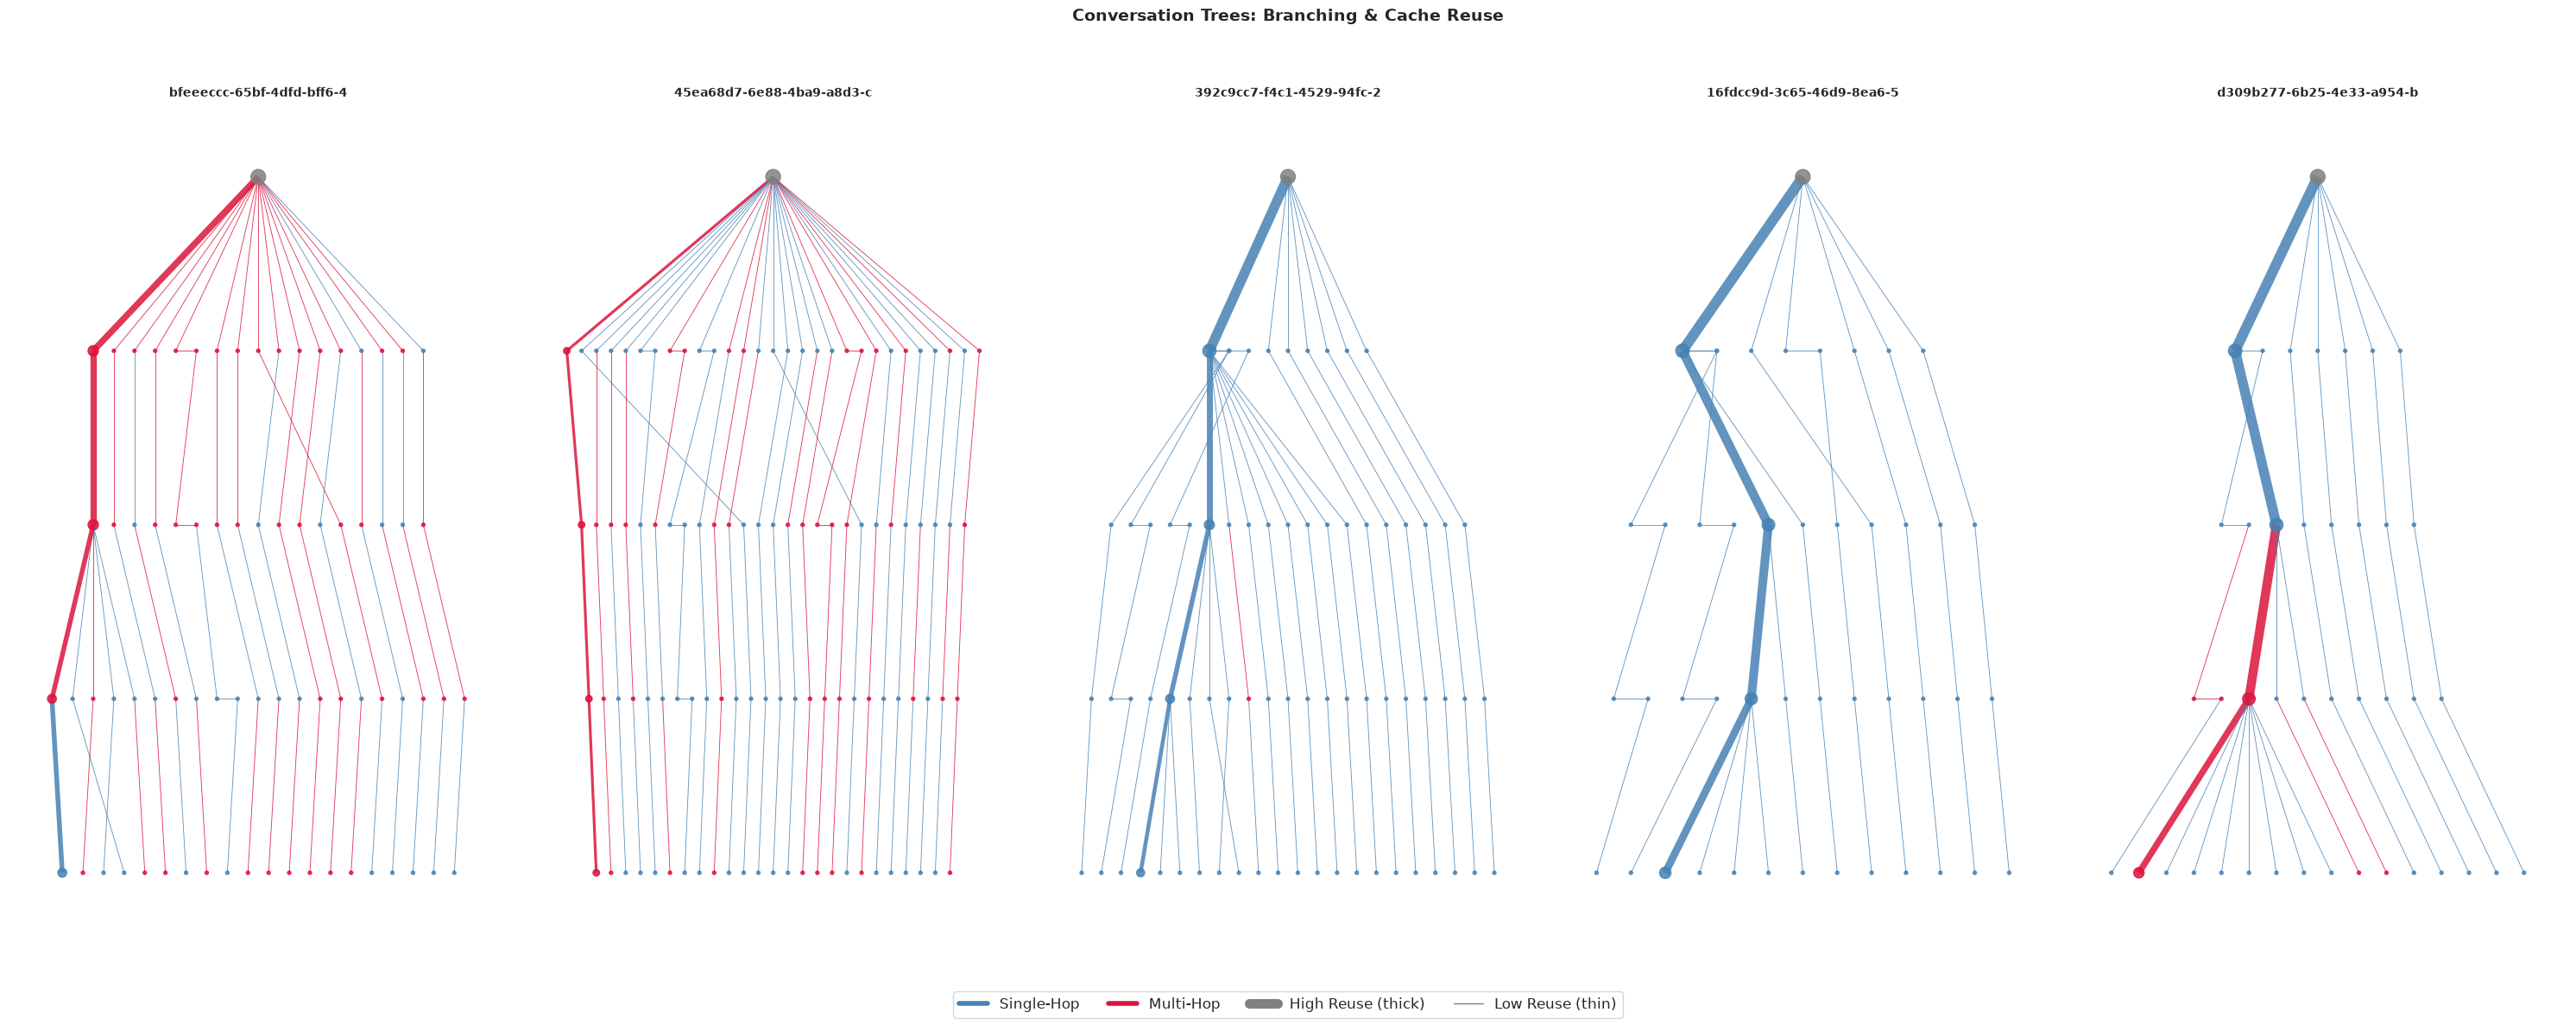

In [38]:
import networkx as nx
from matplotlib.lines import Line2D
from collections import defaultdict

uids = df['uid'].unique()[:5]
fig, axes = plt.subplots(1, 5, figsize=(30, 12))

for ax_idx, uid in enumerate(uids):
    df_tree = df[df['uid'] == uid].copy()
    df_tree['multi_hop'] = df_tree['multi_hop_flag'].isin([True, 'True', 1, 1.0])
    df_tree['cache_hit'] = df_tree['cache_accepted_and_used'].isin([True, 'True', 1, 1.0])
    
    G = nx.DiGraph()
    G.add_node("ROOT", multi_hop=False, depth=0)
    node_counts = defaultdict(int)
    
    for conv_id in sorted(df_tree['conversation_id'].unique()):
        conv = df_tree[df_tree['conversation_id'] == conv_id].sort_values('turn_index')
        parent = "ROOT"
        node_counts["ROOT"] += 1
        
        for _, row in conv.iterrows():
            turn = int(row['turn_index'])
            if turn == 0:
                continue
            
            # Cache-Hit = gleicher Ast, Cache-Miss = neuer Zweig
            if row['cache_hit']:
                node_id = f"{parent}>>T{turn}_hit"
            else:
                node_id = f"{parent}>>T{turn}_miss_{conv_id}"
            
            if not G.has_node(node_id):
                G.add_node(node_id, multi_hop=row['multi_hop'], depth=turn)
            
            node_counts[node_id] += 1
            if not G.has_edge(parent, node_id):
                G.add_edge(parent, node_id)
            
            parent = node_id
    
    # Hierarchisches Layout
    pos = {"ROOT": (0, 0)}
    max_depth = int(df_tree['turn_index'].max())
    for depth in range(1, max_depth + 1):
        nodes_at_depth = sorted([n for n, d in G.nodes(data=True) if d.get('depth') == depth])
        for i, node in enumerate(nodes_at_depth):
            pos[node] = ((i - (len(nodes_at_depth) - 1) / 2), -depth)
    
    # Dicke & Farbe basierend auf Reuse-Count
    max_count = max(node_counts.values()) if node_counts else 1
    
    edge_widths = [node_counts.get(v, 1) / max_count * 10 + 0.3 for u, v in G.edges()]
    edge_colors = ['crimson' if G.nodes[v].get('multi_hop') else 'steelblue' for u, v in G.edges()]
    
    node_colors = []
    node_sizes = []
    for n in G.nodes():
        if n == "ROOT":
            node_colors.append('grey')
        elif G.nodes[n].get('multi_hop'):
            node_colors.append('crimson')
        else:
            node_colors.append('steelblue')
        node_sizes.append(max(node_counts.get(n, 1) / max_count * 150, 8))
    
    nx.draw(G, pos, ax=axes[ax_idx],
            node_size=node_sizes, node_color=node_colors,
            edge_color=edge_colors, width=edge_widths,
            arrows=False, alpha=0.85)
    
    axes[ax_idx].set_title(uid[:25], fontweight='bold', fontsize=10)

legend_handles = [
    Line2D([0], [0], color='steelblue', linewidth=4, label='Single-Hop'),
    Line2D([0], [0], color='crimson', linewidth=4, label='Multi-Hop'),
    Line2D([0], [0], color='grey', linewidth=8, label='High Reuse (thick)'),
    Line2D([0], [0], color='grey', linewidth=1, label='Low Reuse (thin)'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=12)
plt.suptitle('Conversation Trees: Branching & Cache Reuse', fontweight='bold', fontsize=14)
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig('conversation_trees.pdf')
plt.show()

            Cache Available (%)  Cache Hit Rate - All (%)  \
Single-Hop                71.85                     57.14   
Multi-Hop                 62.00                     46.00   

            Cache Hit Rate - If Available (%)    N  
Single-Hop                              79.53  476  
Multi-Hop                               74.19  150  


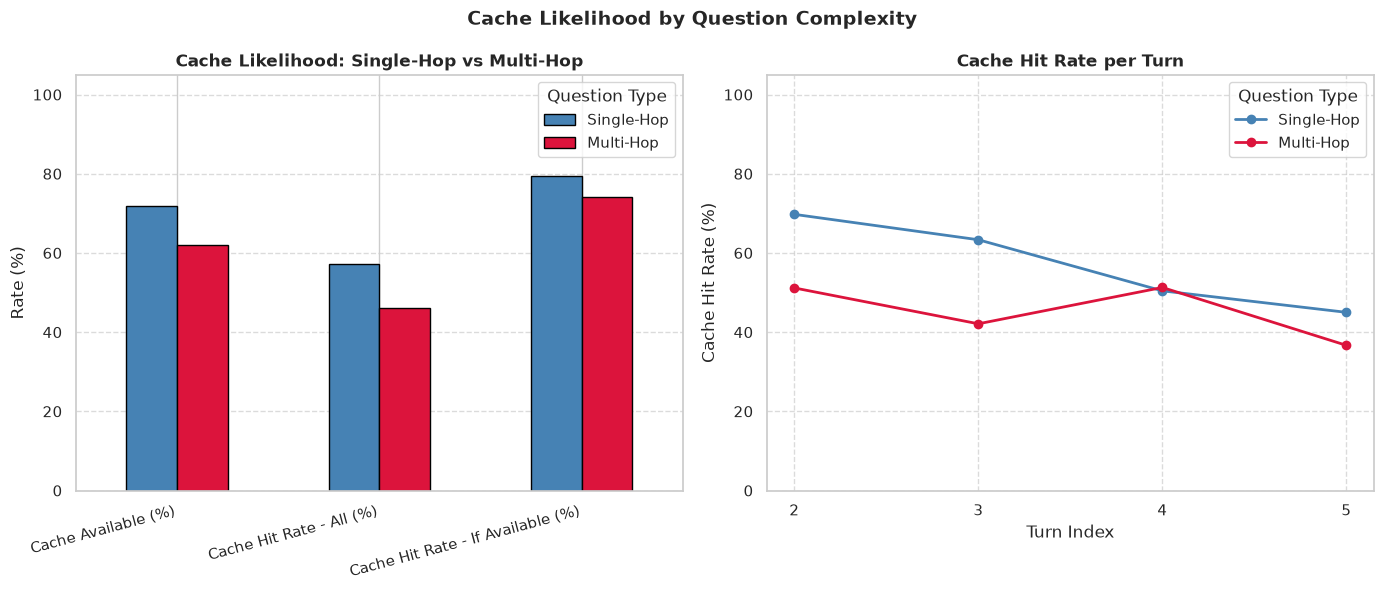

In [43]:
df_turns = df[df['turn_index'] > 0].copy()
df_turns['multi_hop'] = df_turns['multi_hop_flag'].isin([True, 'True', 1, 1.0])
df_turns['cache_avail'] = df_turns['cache_available'].isin([True, 'True', 1, 1.0])
df_turns['cache_hit'] = df_turns['cache_accepted_and_used'].isin([True, 'True', 1, 1.0])

# ============ Berechnung ============
avail = df_turns.groupby('multi_hop')['cache_avail'].mean() * 100
hit_all = df_turns.groupby('multi_hop')['cache_hit'].mean() * 100
df_avail_only = df_turns[df_turns['cache_avail']]
hit_if_avail = df_avail_only.groupby('multi_hop')['cache_hit'].mean() * 100

summary = pd.DataFrame({
    'Cache Available (%)': avail,
    'Cache Hit Rate - All (%)': hit_all,
    'Cache Hit Rate - If Available (%)': hit_if_avail,
    'N': df_turns.groupby('multi_hop').size()
})
summary.index = ['Single-Hop', 'Multi-Hop']
print(summary.round(2))

# ============ Plot ============
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Bar: Vergleich der Raten
plot_data = summary[['Cache Available (%)', 'Cache Hit Rate - All (%)', 'Cache Hit Rate - If Available (%)']].T
plot_data.plot(kind='bar', ax=ax1, color=['steelblue', 'crimson'], edgecolor='black')
ax1.set_title('Cache Likelihood: Single-Hop vs Multi-Hop', fontweight='bold')
ax1.set_ylabel('Rate (%)')
ax1.set_ylim(0, 105)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15, ha='right')
ax1.legend(title='Question Type')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

turn_hop = df_turns.groupby(['turn_index', 'multi_hop'])['cache_hit'].mean().unstack() * 100
turn_hop.columns = ['Single-Hop', 'Multi-Hop']
turn_hop.index = turn_hop.index.astype(int) + 1  # VOR dem Plot

turn_hop.plot(ax=ax2, marker='o', color=['steelblue', 'crimson'], linewidth=2)
ax2.set_title('Cache Hit Rate per Turn', fontweight='bold')
ax2.set_xlabel('Turn Index')
ax2.set_ylabel('Cache Hit Rate (%)')
ax2.set_ylim(0, 105)
ax2.set_xticks(turn_hop.index.astype(int))
ax2.legend(title='Question Type')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Cache Likelihood by Question Complexity', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('cache_likelihood_hop_turns.pdf')
plt.show()